# 数据集预处理
针对单个数据集进行严格的：
- 设置随机种子
- 样本筛选
- 细胞质控
- 去除环境污染（是否需要？）
- 保存质控后数据至'UC/scRNA-seq_data/03_qc_filtered'文件夹
- 批次效应查看
- 降维聚类结果
- 处理异常细胞群
- 区分主要谱系

# 文件说明
- **文件名**: 11_GSE235663_qc.h5ad 
- **存放位置**: 坚果云  `UC/scRNA-seq_data/03_qc_filtered/`  
- **生成日期**: 2025-11-3  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.2_qc_filtered/11_GSE235663.ipynb  
- **内容说明**: 完成了针对单个数据的预处理工作，包括样本排除、细胞质控，并查看了样本间的批次效应。  

In [1]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [2]:
import scanpy as sc
sc.settings.verbosity = 1
print(sc.__version__)

1.9.6


/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarn

## 读取数据
GSE135663数据集：
- 结肠组织 T细胞
- 3UC，1HC

In [4]:
adata = sc.read_h5ad('/Users/future/Nutstore Files/UC/scRNA-seq_data/02_sample_merge/11_GSE235663.h5ad')

In [5]:
adata

AnnData object with n_obs × n_vars = 11042 × 14202
    obs: 'n_genes', 'id', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'mt'
    uns: 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

In [6]:
adata.obs.head()

,n_genes,id,GSM,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
AAACCTGAGCTACCGC.2,2775,UC75,GSM7507205,7596,0.0,2775,0.365324,True,True,True,0.230530,False
AAACCTGAGTGCGATG.2,1274,UC75,GSM7507205,3788,0.0,1274,0.336325,True,True,True,0.012750,False
AAACCTGCAGGATCGA.2,1124,UC75,GSM7507205,3223,0.0,1124,0.348743,True,True,True,0.020338,False
AAACCTGGTTTAGGAA.2,2639,UC75,GSM7507205,7107,0.0,2639,0.371324,True,True,True,0.182278,False
AAACCTGTCCCTTGCA.2,1587,UC75,GSM7507205,5273,0.0,1587,0.300967,True,True,True,0.031504,False


## 处理细胞标签及分组

In [7]:
# 提取分组信息
import pandas as pd
adata.obs['group'] = adata.obs['id'].str.extract(r'([A-Za-z]+)', expand=False)
print(adata.obs[['id', 'group']].head())

                      id group
AAACCTGAGCTACCGC.2  UC75    UC
AAACCTGAGTGCGATG.2  UC75    UC
AAACCTGCAGGATCGA.2  UC75    UC
AAACCTGGTTTAGGAA.2  UC75    UC
AAACCTGTCCCTTGCA.2  UC75    UC


`.obs`当中只保留GSM信息和分组信息

In [9]:
adata.obs.drop(columns=['id'], inplace=True)
print(adata.obs.head())

                    n_genes         GSM  nUMIs  mito_perc  detected_genes  \
AAACCTGAGCTACCGC.2     2775  GSM7507205   7596        0.0            2775   
AAACCTGAGTGCGATG.2     1274  GSM7507205   3788        0.0            1274   
AAACCTGCAGGATCGA.2     1124  GSM7507205   3223        0.0            1124   
AAACCTGGTTTAGGAA.2     2639  GSM7507205   7107        0.0            2639   
AAACCTGTCCCTTGCA.2     1587  GSM7507205   5273        0.0            1587   

                    cell_complexity  passing_mt  passing_nUMIs  \
AAACCTGAGCTACCGC.2         0.365324        True           True   
AAACCTGAGTGCGATG.2         0.336325        True           True   
AAACCTGCAGGATCGA.2         0.348743        True           True   
AAACCTGGTTTAGGAA.2         0.371324        True           True   
AAACCTGTCCCTTGCA.2         0.300967        True           True   

                    passing_ngenes  doublet_score  predicted_doublet group  
AAACCTGAGCTACCGC.2            True       0.230530              

In [10]:
adata.obs['group'].value_counts()

group
UC    7576
HC    3466
Name: count, dtype: int64

## 样本质量查看

In [11]:
adata.obs['GSM'].value_counts()

GSM
GSM7507220    4940
GSM7507206    3466
GSM7507205    1936
GSM7507217     700
Name: count, dtype: int64

In [12]:
sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])

print(sample_quality_stats)

                n_genes                               nUMIs                    \
                   mean         std  min   max         mean          std  min   
GSM                                                                             
GSM7507205  1499.469525  496.556473  370  2969  3742.997417  1673.375224  534   
GSM7507206  1508.266590  502.809362  376  2976  3744.642816  1659.132886  540   
GSM7507217  1432.140000  505.412061  376  2993  3379.498571  1599.571749  579   
GSM7507220  1700.179960  523.853601  331  2995  4180.521255  1792.434227  507   

                     mito_perc                           
             max          mean       std  min       max  
GSM                                                      
GSM7507205  8945  5.400125e-07  0.000013  0.0  0.000348  
GSM7507206  8977  3.803704e-07  0.000011  0.0  0.000498  
GSM7507217  8987  2.007936e-06  0.000031  0.0  0.000735  
GSM7507220  8995  1.635915e-06  0.000027  0.0  0.001041  


/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_44515/2761774101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])


## 细胞质控

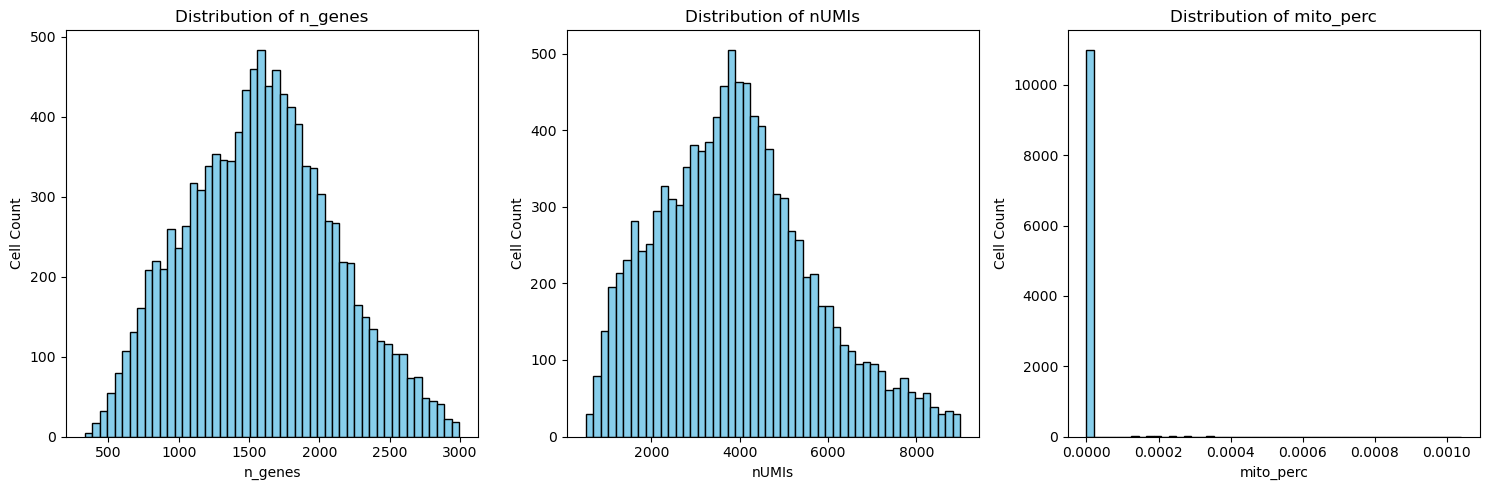

In [13]:
import matplotlib.pyplot as plt

# 选择要可视化的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 绘制各个指标的直方图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 绘制每个质量控制指标的直方图
for i, metric in enumerate(qc_metrics):
    ax[i].hist(adata.obs[metric], bins=50, color='skyblue', edgecolor='black')
    ax[i].set_title(f'Distribution of {metric}')
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Cell Count')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_44515/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

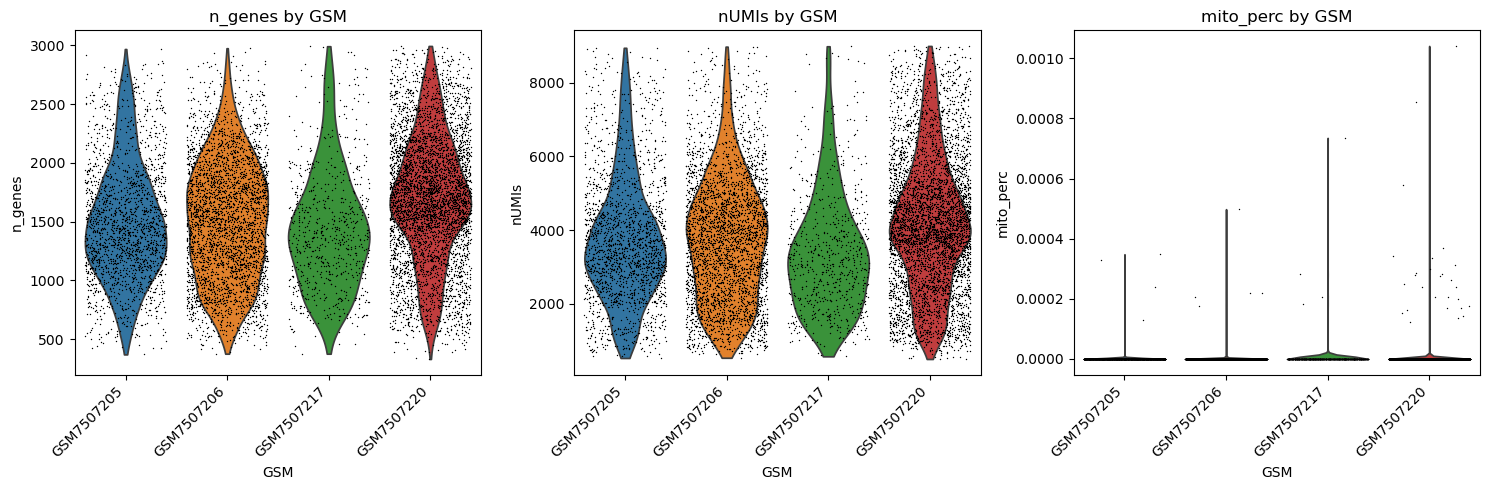

In [14]:
# 设置绘图风格
sc.settings.verbosity = 0  # 简化日志输出

# 选择要绘制的小提琴图的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 按照样本（GSM）绘制小提琴图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(qc_metrics):
    sc.pl.violin(adata, keys=metric, groupby='GSM', ax=ax[i], stripplot=True, jitter=0.4, show=False)
    ax[i].set_title(f'{metric} by GSM')
    ax[i].set_ylabel(f'{metric}')
    
    # 获取当前的x轴标签
    labels = ax[i].get_xticklabels()
    # 旋转标签并调整对齐方式（末尾对齐）
    ax[i].set_xticklabels(labels, rotation=45, ha='right')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


### 严格细胞质控标准
- min_genes = 200          # 最少基因数
- max_genes = 4000         # 最多基因数
- min_umis = 500           # 最少UMI数量
- max_umis = 20000         # 最多UMI数量
- max_mito_perc = 10       # 线粒体基因百分比最大值

In [15]:
# 设置阈值
min_genes = 200          # 最少基因数
max_genes = 6000         # 最多基因数
min_umis = 500           # 最少UMI数量
max_umis = 20000        # 最多UMI数量
max_mito_perc = 0.1       # 线粒体基因百分比最大值

# 根据阈值进行过滤
adata = adata[(adata.obs['n_genes'] > min_genes) & 
              (adata.obs['n_genes'] < max_genes) &
              (adata.obs['nUMIs'] > min_umis) &
              (adata.obs['nUMIs'] < max_umis) &
              (adata.obs['mito_perc'] < max_mito_perc), :]

# 输出过滤后的细胞数
print(f'Number of cells after filtering: {adata.n_obs}')

Number of cells after filtering: 11042


## 保存质控后数据


In [16]:
import os
output_dir = "/Users/future/Nutstore Files/UC/scRNA-seq_data/03_qc_filtered/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "11_GSE235663_qc.h5ad"), compression='gzip')

## 降维聚类

In [ ]:
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

血液组织细胞，所以选取2000个高变基因  
大致分别谱系，所以选取resolution=0.4

In [ ]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.4)

In [ ]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

In [ ]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## 去除批次效应
按样本去除批次，看看是否效果会更好

使用`harmony`

In [ ]:
ov.single.batch_correction(adata,
                           batch_key='GSM', # 去批次分组标签
                           methods='harmony',
                           n_pcs=50)
                           
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='X_harmony')

ov.pp.umap(adata)

ov.pp.leiden(adata,resolution=0.4)

In [ ]:
# 可视化查看去除批次效应后聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

In [ ]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## GPT自动注释

In [ ]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

In [ ]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

In [ ]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

In [ ]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [ ]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)